# UTS - Kasus 3: Disaster Tweets (Text)

## 0. Setup & Reproducibility
Tahap ini menyiapkan library NLP klasik dan deep learning, serta seed untuk replikasi eksperimen.

In [29]:
# Tahap setup: validasi environment venv dan import library yang dibutuhkan.
# Jalankan `pip install -r requirements.txt` terlebih dahulu sebelum membuka notebook ini.
required_modules = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'torch']
missing_modules = []
for module_name in required_modules:
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        missing_modules.append(module_name)

if missing_modules:
    raise ModuleNotFoundError(
        'Ada package yang belum terpasang: ' + ', '.join(missing_modules) +
        '. Jalankan `pip install -r requirements.txt` pada environment aktif.'
    )

# Tahap setup: import library untuk preprocessing teks, baseline ML, dan model deep learning.
import re
import time
import random
import warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')


In [30]:
# Tahap reproducibility: menetapkan seed agar pembagian data dan training konsisten.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CONFIG = {'seed': SEED, 'test_size': 0.2, 'val_size': 0.2, 'max_vocab': 20000, 'max_len': 50}
print('Konfigurasi aktif:', CONFIG)


Konfigurasi aktif: {'seed': 42, 'test_size': 0.2, 'val_size': 0.2, 'max_vocab': 20000, 'max_len': 50}


## 1. EDA
Tahap ini memeriksa karakteristik dataset tweet, distribusi label, dan contoh teks.

In [31]:
# Tahap EDA: membuat cache lokal lalu mengunduh data tweets jika file belum tersedia.
import urllib.request

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / '.cache' / 'datasets' / 'tweets'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def download_if_missing(urls, out_path):
    if out_path.exists():
        return out_path
    for url in urls:
        try:
            print(f'Download: {url}')
            urllib.request.urlretrieve(url, out_path)
            return out_path
        except Exception as e:
            print(f'Gagal dari {url}: {e}')
    return None

train_urls = [
    'https://raw.githubusercontent.com/Krishnarohith10/nlp-getting-started/master/train.csv'
]
cached_train = download_if_missing(train_urls, CACHE_DIR / 'train.csv')

TRAIN_CANDIDATES = [
    cached_train,
    BASE_DIR / 'data' / 'tweets' / 'train.csv',
    BASE_DIR / 'datasets' / 'tweets' / 'train.csv',
    BASE_DIR / 'train.csv',
]
TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if (p is not None and p.exists())), None)
if TRAIN_PATH is None:
    raise FileNotFoundError(
        'File tweets train.csv tidak ditemukan. Pastikan internet aktif atau simpan train.csv di data/tweets/.'
    )

df = pd.read_csv(TRAIN_PATH)
print('Path train:', TRAIN_PATH)
print('Ukuran data:', df.shape)
df.head()


Path train: c:\Users\muham\Kuliah\Ekstensi\Semester Genap 25-26\Pengantar Deep Learning\UTS\notebooks\.cache\datasets\tweets\train.csv
Ukuran data: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

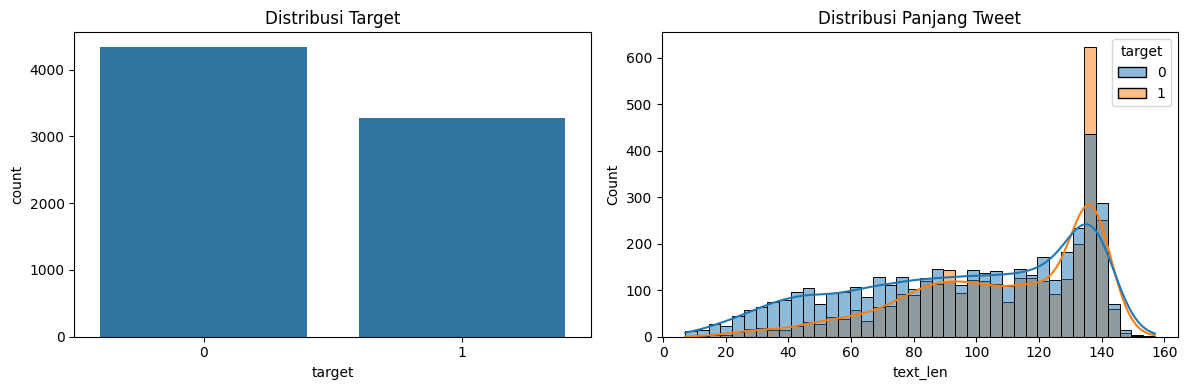

In [32]:
# Tahap EDA: melihat distribusi target dan panjang teks sebagai insight awal.
display(df['target'].value_counts(normalize=True))
df['text_len'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='target', ax=axes[0])
axes[0].set_title('Distribusi Target')
sns.histplot(data=df, x='text_len', hue='target', bins=40, ax=axes[1], kde=True)
axes[1].set_title('Distribusi Panjang Tweet')
plt.tight_layout()
plt.show()


## 2. Preprocessing
Tahap ini melakukan pembersihan teks, split data konsisten, dan persiapan input untuk baseline serta model deep learning.

In [33]:
# Tahap preprocessing: fungsi pembersihan teks (lowercase, hapus URL, mention, dan karakter non-alfanumerik).
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
display(df[['text', 'text_clean']].head())


,text,text_clean
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this may allah for...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive evacuation orders in cal...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby as smoke fr...


In [34]:
# Tahap preprocessing: split train/val/test agar evaluasi antar model fair.
X = df['text_clean']
y = df['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=CONFIG['val_size'], random_state=SEED, stratify=y_train_full
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (4872,) Val: (1218,) Test: (1523,)


## 3. Baseline ML
Tahap ini melatih minimal 2 kombinasi baseline berbasis TF-IDF untuk pembanding model deep learning.

In [35]:
# Tahap baseline ML: TF-IDF (unigram+bigram) + Logistic Regression.
baseline_results = []

tfidf_logreg = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)),
    ('clf', LogisticRegression(max_iter=400, random_state=SEED))
])

start = time.perf_counter()
tfidf_logreg.fit(X_train, y_train)
logreg_time = time.perf_counter() - start
pred_val = tfidf_logreg.predict(X_val)
f1 = f1_score(y_val, pred_val)
baseline_results.append({'model': 'TFIDF+LogReg', 'val_f1': f1, 'train_time_sec': logreg_time})
print('TFIDF+LogReg val F1:', round(f1, 4))


TFIDF+LogReg val F1: 0.735


In [36]:
# Tahap baseline ML: TF-IDF (unigram+bigram) + Linear SVM sebagai baseline kedua.
tfidf_svm = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)),
    ('clf', LinearSVC(random_state=SEED))
])

start = time.perf_counter()
tfidf_svm.fit(X_train, y_train)
svm_time = time.perf_counter() - start
pred_val = tfidf_svm.predict(X_val)
f1 = f1_score(y_val, pred_val)
baseline_results.append({'model': 'TFIDF+LinearSVM', 'val_f1': f1, 'train_time_sec': svm_time})
print('TFIDF+LinearSVM val F1:', round(f1, 4))
pd.DataFrame(baseline_results)


TFIDF+LinearSVM val F1: 0.738


,model,val_f1,train_time_sec
0,TFIDF+LogReg,0.735043,0.473509
1,TFIDF+LinearSVM,0.738000,0.208650


## 4. Deep Learning
Tahap ini membangun model Embedding + BiLSTM sebagai pendekatan deep learning untuk klasifikasi teks.

In [37]:
# Tahap deep learning: tokenisasi teks dan padding sequence untuk input BiLSTM PyTorch.
def simple_tokenize(text):
    return str(text).split()

counter = Counter()
for t in X_train:
    counter.update(simple_tokenize(t))

vocab_items = counter.most_common(CONFIG['max_vocab'] - 2)
vocab = {w: i + 2 for i, (w, _) in enumerate(vocab_items)}
PAD_IDX = 0
OOV_IDX = 1

def encode_and_pad(text, vocab_map, max_len, pad_idx=0, oov_idx=1):
    tokens = simple_tokenize(text)
    ids = [vocab_map.get(tok, oov_idx) for tok in tokens][:max_len]
    if len(ids) < max_len:
        ids += [pad_idx] * (max_len - len(ids))
    return ids

X_train_pad = np.array([encode_and_pad(t, vocab, CONFIG['max_len'], PAD_IDX, OOV_IDX) for t in X_train], dtype=np.int64)
X_val_pad = np.array([encode_and_pad(t, vocab, CONFIG['max_len'], PAD_IDX, OOV_IDX) for t in X_val], dtype=np.int64)
X_test_pad = np.array([encode_and_pad(t, vocab, CONFIG['max_len'], PAD_IDX, OOV_IDX) for t in X_test], dtype=np.int64)

print('Ukuran vocab:', len(vocab) + 2)
print('Shape input BiLSTM:', X_train_pad.shape)


Ukuran vocab: 10602
Shape input BiLSTM: (4872, 50)


In [38]:
# Tahap deep learning: definisi arsitektur BiLSTM PyTorch dan proses training dengan early stopping.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_train_dl = y_train.to_numpy(dtype=np.float32)
y_val_dl = y_val.to_numpy(dtype=np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_pad), torch.from_numpy(y_train_dl.reshape(-1, 1)))
val_ds = TensorDataset(torch.from_numpy(X_val_pad), torch.from_numpy(y_val_dl.reshape(-1, 1)))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.drop = nn.Dropout(0.3)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        h_cat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        x = torch.relu(self.fc1(h_cat))
        x = self.drop(x)
        return self.out(x)

vocab_size = len(vocab) + 2
bilstm = BiLSTMClassifier(vocab_size=vocab_size, pad_idx=PAD_IDX).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(bilstm.parameters(), lr=1e-3)

best_val_loss = float('inf')
best_state = None
patience = 4
wait = 0
max_epochs = 10

start = time.perf_counter()
for epoch in range(max_epochs):
    bilstm.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = bilstm(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    bilstm.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = bilstm(xb)
            vloss = criterion(logits, yb)
            val_losses.append(vloss.item())

    avg_val_loss = float(np.mean(val_losses))
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in bilstm.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

if best_state is not None:
    bilstm.load_state_dict(best_state)

dl_time = time.perf_counter() - start
print('Training BiLSTM PyTorch selesai, durasi (detik):', round(dl_time, 2))


Training BiLSTM PyTorch selesai, durasi (detik): 14.5


## 5. Evaluasi
Tahap ini membandingkan performa model menggunakan metrik utama F1-Score sesuai ketentuan tugas.

In [39]:
# Tahap evaluasi: menghitung metrik untuk semua model pada test set.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bilstm.eval()
with torch.no_grad():
    test_logits = bilstm(torch.from_numpy(X_test_pad).to(device)).cpu().numpy().ravel()
test_proba = 1 / (1 + np.exp(-test_logits))
test_pred_dl = (test_proba >= 0.5).astype(int)

models = {'TFIDF+LogReg': tfidf_logreg, 'TFIDF+LinearSVM': tfidf_svm}
test_preds = {}
for name, model in models.items():
    test_preds[name] = model.predict(X_test)
test_preds['BiLSTM'] = test_pred_dl

eval_results = []
for name, pred in test_preds.items():
    eval_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1_score': f1_score(y_test, pred)
    })
comparison_df = pd.DataFrame(eval_results)
display(comparison_df.sort_values('f1_score', ascending=False))


,model,accuracy,precision,recall,f1_score
1,TFIDF+LinearSVM,0.791858,0.773984,0.727829,0.750197
0,TFIDF+LogReg,0.801051,0.819672,0.688073,0.748130
2,BiLSTM,0.732108,0.671788,0.735474,0.702190


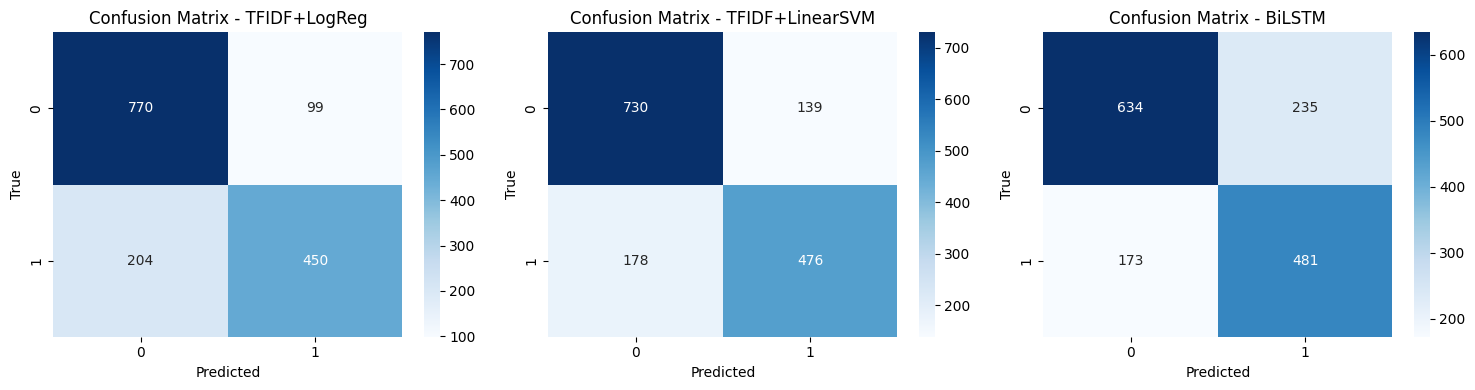

In [40]:
# Tahap evaluasi: menampilkan confusion matrix untuk semua model (side-by-side).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


## 6. Error Analysis
Tahap ini menampilkan contoh tweet yang salah prediksi, lalu menganalisis pola error (misalnya negasi, sarkasme, konteks ambigu).

In [41]:
import pandas as pd

# Kumpulkan teks asli dan hasil prediksi ke dalam DataFrame
error_df = pd.DataFrame({
    'Tweet_Text': X_test,  # X_test adalah Series/Array berisi raw text tweet
    'Actual_Label': y_test.values if hasattr(y_test, 'values') else y_test,
    'Pred_LogReg': test_preds['TFIDF+LogReg'],
    'Pred_LinearSVM': test_preds['TFIDF+LinearSVM'],
    'Pred_BiLSTM': test_preds['BiLSTM']
})

# Mapping label ke string agar mudah dibaca
label_map = {0: 'Not Disaster', 1: 'Disaster'}
error_df['Actual_Label_Str'] = error_df['Actual_Label'].map(label_map)
error_df['Pred_LogReg_Str'] = error_df['Pred_LogReg'].map(label_map)
error_df['Pred_LinearSVM_Str'] = error_df['Pred_LinearSVM'].map(label_map)
error_df['Pred_BiLSTM_Str'] = error_df['Pred_BiLSTM'].map(label_map)

# Filter hanya kolom string dan text
cols_to_show = ['Tweet_Text', 'Actual_Label_Str', 'Pred_LogReg_Str', 'Pred_LinearSVM_Str', 'Pred_BiLSTM_Str']
display_df = error_df[cols_to_show]

# 1. Cari tweet yang salah ditebak oleh BiLSTM (DL)
dl_errors = display_df[display_df['Actual_Label_Str'] != display_df['Pred_BiLSTM_Str']]
print(f"Total kesalahan prediksi BiLSTM: {len(dl_errors)} dari {len(y_test)} tweets")
print("\n--- 5 Contoh Tweet yang Salah Ditebak oleh BiLSTM PyTorch ---")
pd.set_option('display.max_colwidth', None) # Agar teks tweet terlihat penuh
display(dl_errors.head())

# 2. Cari tweet yang salah ditebak oleh SEMUA model (Hard Examples)
all_errors = display_df[
    (display_df['Actual_Label_Str'] != display_df['Pred_LogReg_Str']) &
    (display_df['Actual_Label_Str'] != display_df['Pred_LinearSVM_Str']) &
    (display_df['Actual_Label_Str'] != display_df['Pred_BiLSTM_Str'])
]
print(f"\nTotal tweet yang salah ditebak oleh KETIGA model: {len(all_errors)}")
print("--- 5 Contoh Tweet yang Sangat Sulit Ditebak (Sarkasme / Konteks Sulit) ---")
display(all_errors.head())
pd.reset_option('display.max_colwidth')


Total kesalahan prediksi BiLSTM: 408 dari 1523 tweets

--- 5 Contoh Tweet yang Salah Ditebak oleh BiLSTM PyTorch ---


,Tweet_Text,Actual_Label_Str,Pred_LogReg_Str,Pred_LinearSVM_Str,Pred_BiLSTM_Str
4863,step one get that mass murderer s portrait off the yuan,Not Disaster,Disaster,Disaster,Disaster
6837,hollywood movie about trapped miners released in chile the 33 hollywood movie about trapped miners starring,Disaster,Not Disaster,Not Disaster,Not Disaster
2905,i can t drown my demons they know how to swim,Disaster,Not Disaster,Not Disaster,Not Disaster
4668,megalpolis area petting party shiver fear instant global inundation overflow was commencement write,Not Disaster,Not Disaster,Not Disaster,Disaster
4256,something frightening is happening to the weather in the middle east,Disaster,Disaster,Disaster,Not Disaster



Total tweet yang salah ditebak oleh KETIGA model: 170
--- 5 Contoh Tweet yang Sangat Sulit Ditebak (Sarkasme / Konteks Sulit) ---


,Tweet_Text,Actual_Label_Str,Pred_LogReg_Str,Pred_LinearSVM_Str,Pred_BiLSTM_Str
4863,step one get that mass murderer s portrait off the yuan,Not Disaster,Disaster,Disaster,Disaster
6837,hollywood movie about trapped miners released in chile the 33 hollywood movie about trapped miners starring,Disaster,Not Disaster,Not Disaster,Not Disaster
2905,i can t drown my demons they know how to swim,Disaster,Not Disaster,Not Disaster,Not Disaster
1358,if firefighters acted like cops they d drive around shooting a flamethrower at burning buildings,Not Disaster,Disaster,Disaster,Disaster
5020,it looks like a mudslide poor thing,Disaster,Not Disaster,Not Disaster,Not Disaster
